# Physical Experiment Notch 2: Multibeam Structures (serie, triangle) (DO NOT EDIT!)

This notebook continues to research the accuracy of the physical beam filters. Where `experiment_notch_phys_1.ipynb`'s main purpose was to calibrate single beams and obtain accurate results for these single beam structures, this notebook expands the structure complexity and first builds a two beam serie, whereafter we continue constructing a triangle.

Let us first import our required modules:

In [1]:
# Import modules:
from beam_manager import open_beam_library, sublibrary
from bridge_manager_v2 import Bridge
from myDAQ_manager import logs_to_U

import numpy as np
# %matplotlib widget
import matplotlib.pyplot as plt

We construct our serially connected two-beam structure first, using beams `B1` and `B2`:

In [2]:
library_name = 'notchphys1'
library = open_beam_library(library_name + '.json')
selection = ['A1'] # U_in attached to B2
lib = sublibrary(selection, library)

R_ref = 98.4 # Ohm (B1)
f_logrange = (2, np.log10(2e4)) # max frequency sweep between 100 and 20 000 Hz (audio range)

topology = [(0, 1)]
struc = Bridge()
struc.construct(lib, topology)

Let's try to do some predictions on the serial structure!

R-values found, generating plot...
The solver predicted [535.40569033], while the resistance values were [536].


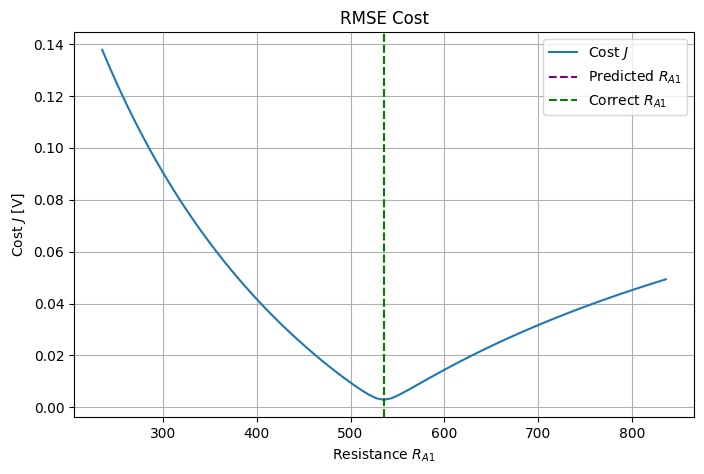

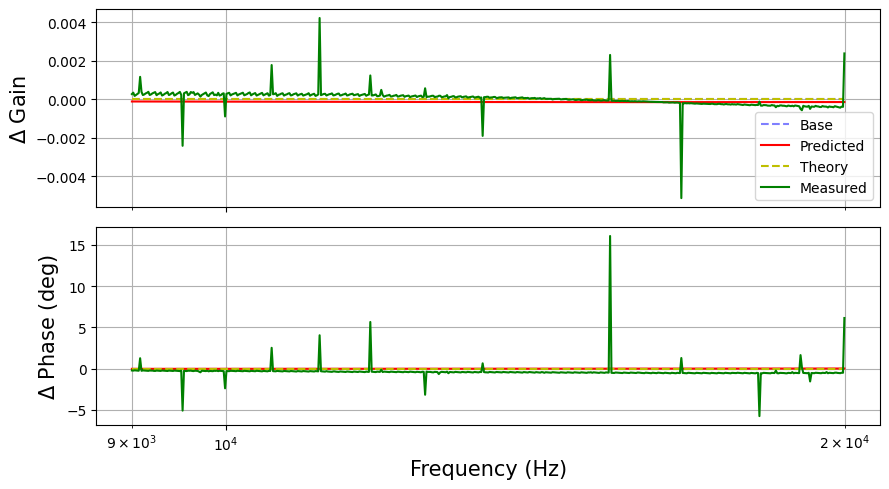

In [3]:
# Import measurement logs:
filename = 'A1-536ohm-9-20kHz-2.1.txt'
f_arr_mes, gain_mes, phase_mes = logs_to_U(filename, Cartesian=False)
_, U_out_mes = logs_to_U(filename, Cartesian=True)

# Perform prediction:
R_def = [536] # Initial resistance for our build filter!

R_pred = struc.predict_R(R_ref, myDAQ=True, f_arr_mes=f_arr_mes, U_out_mes=U_out_mes, resonance_sweep=False, 
                         error_plot=True, R_var=[0], R_def=R_def, response_comparison_plot=True, include_mes=True)

print(f"The solver predicted {R_pred}, while the resistance values were {R_def}.")

To see what the solver tried to fit, we plot the theoretical response for the correct deformation resistances, the measured response and the fitted response:

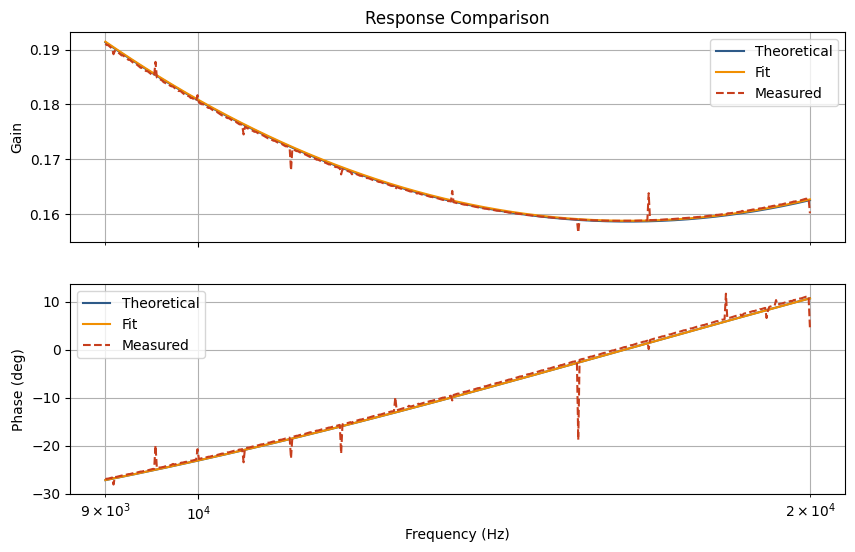

In [4]:
U_th = struc.solve_U(f_arr_mes, R_ref, R_vec=R_def)
gain_th = np.abs(U_th)
phase_th = np.degrees(np.angle(U_th))

U_f = struc.solve_U(f_arr_mes, R_ref, R_vec=R_pred)
gain_f = np.abs(U_f)
phase_f = np.degrees(np.angle(U_f))

gain = [gain_th, gain_f, gain_mes]
phase = [phase_th, phase_f, phase_mes]

colors = ['#2E5A88', '#F18F01', '#C73E1D']
labels = ['Theoretical', 'Fit', 'Measured']
linestyles = ['-', '-', '--']

fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

for gain_i, phase_i, color, label, linestyle in zip(gain, phase, colors, labels, linestyles):
    ax[0].semilogx(f_arr_mes, gain_i, color=color, label=label, linestyle=linestyle)
    ax[1].semilogx(f_arr_mes, phase_i, color=color, label=label, linestyle=linestyle)

ax[0].set_ylabel('Gain')
ax[0].legend()
ax[0].grid(True, which='both')
ax[0].set_title('Response Comparison')
ax[1].set_ylabel('Phase (deg)')
ax[1].set_xlabel('Frequency (Hz)')
ax[1].legend()
ax[1].grid(True, which='both')

Results seem decent! The best results were found for the smaller resistance values (around 250), where the only (slightly) troubling result was found for `R_B2 = 253` and `R_B1 = 753`, with a deviation for `R_B1` of + 30 Ohm. 

Let's try the triangle now. 

In [5]:
selection = ['A1','B2', 'B1'] # U_in attached to B2
lib = sublibrary(selection, library)

R_ref = 98.4 # Ohm (B1)
f_logrange = (2, np.log10(2e4)) # max frequency sweep between 100 and 20 000 Hz (audio range)

topology = [(0,2), (0, 1), (1, 2)]
struc = Bridge()
struc.construct(lib, topology)

We perform the predictions:

R-values found, generating plot...
The solver predicted [261.72115966 525.08761731 294.5875802 ], while the resistance values were [250, 533, 252]


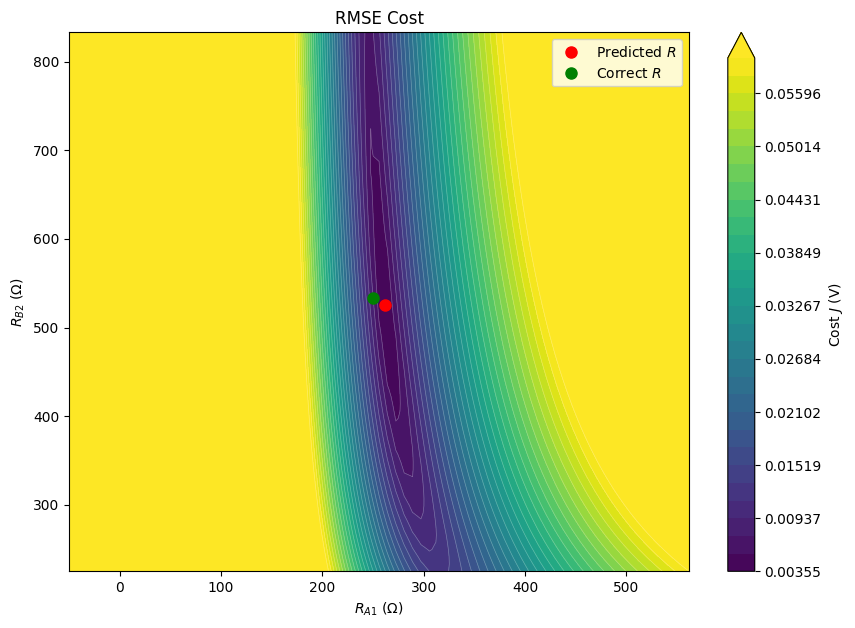

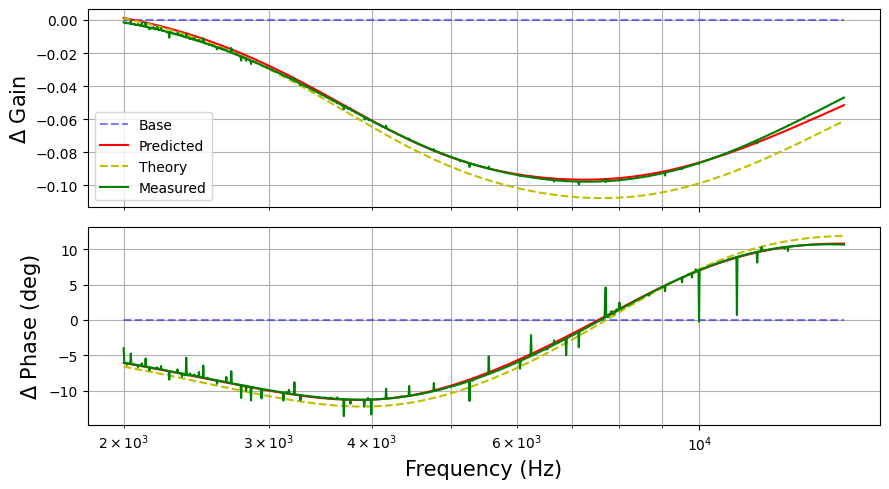

In [6]:
# Import measurement logs:
filename = 'B2-B1-A1-533-252-250ohm-2-15kHz-4.1.txt'
f_arr_mes, gain_mes, phase_mes = logs_to_U(filename, Cartesian=False)
_, U_out_mes = logs_to_U(filename, Cartesian=True)

# Perform prediction:
R_def = [250, 533, 252] # Initial resistance for our build filter!

R_pred = struc.predict_R(R_ref, myDAQ=True, f_arr_mes=f_arr_mes, U_out_mes=U_out_mes, resonance_sweep=False, 
                         error_plot=True, R_var=[0,1], R_def=R_def, response_comparison_plot=True, include_mes=True)

print(f"The solver predicted {R_pred}, while the resistance values were {R_def}")

<!-- TODO -->